In [8]:
# # Region-Level Reorganization Ranking
# 
# **Purpose**: Rank individual regions by misclassification rate during task to identify
# which specific brain areas show the greatest functional reorganization.
# 
# **Thesis Contribution**: Generates key findings connecting classification errors to
# neuroscience—e.g., "motor regions show highest reorganization during button-press task"
# 
# ## Expected Patterns for Gender Stroop Task:
# | Region Type | Expected Reorganization | Reason |
# |-------------|------------------------|--------|
# | Motor regions | HIGH | Button press responses |
# | Visual regions | MODERATE | Stimulus processing |
# | Default Mode | VARIABLE | Task engagement/disengagement |
# | Subcortical | HIGH | Task switching, attention |
# | Language regions | HIGH | Word reading in Gender Stroop |

In [9]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Publication-quality settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Color palette for networks (Schaefer 17 networks + Subcortical)
NETWORK_COLORS = {
    'VisCent': '#781286',      # Purple
    'VisPeri': '#AA23A7',      # Light purple
    'SomMotA': '#4682B4',      # Steel blue
    'SomMotB': '#62A7D7',      # Light blue
    'DorsAttnA': '#00760E',    # Dark green
    'DorsAttnB': '#4A9B50',    # Medium green
    'SalVentAttnA': '#C43AFA', # Magenta
    'SalVentAttnB': '#EB9ADB', # Pink
    'LimbicA': '#DCDC5A',      # Yellow-green
    'LimbicB': '#E3E36E',      # Light yellow
    'ContA': '#E69422',        # Orange
    'ContB': '#F4B54F',        # Light orange
    'ContC': '#F9D280',        # Pale orange
    'DefaultA': '#CD3E4E',     # Red
    'DefaultB': '#E26A76',     # Light red
    'DefaultC': '#F09AA1',     # Pink
    'TempPar': '#1A53A4',      # Navy blue
    'Subcortical': '#708090',  # Slate gray
}

# Simplified network groups for analysis
NETWORK_GROUPS = {
    'Visual': ['VisCent', 'VisPeri'],
    'Somatomotor': ['SomMotA', 'SomMotB'],
    'Dorsal Attention': ['DorsAttnA', 'DorsAttnB'],
    'Salience/VentAttn': ['SalVentAttnA', 'SalVentAttnB'],
    'Limbic': ['LimbicA', 'LimbicB'],
    'Control': ['ContA', 'ContB', 'ContC'],
    'Default Mode': ['DefaultA', 'DefaultB', 'DefaultC'],
    'Temporal Parietal': ['TempPar'],
    'Subcortical': ['Subcortical']
}

print("✓ Imports complete")

✓ Imports complete


In [13]:
BASE_DIR = Path("/home/sjoon/projects/brain_connectivity_classifier/data/results")
OUTPUT_DIR = Path("reports/region_level_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define paths for per-region metrics
# CV (rest) results
CV_PATHS = {
    'full': BASE_DIR / "full_connectivity_analysis/multinomial/per_region_metrics.csv",
    'left': BASE_DIR / "hemisphere_analysis/left_hemisphere/multinomial/per_region_metrics.csv",
    'right': BASE_DIR / "hemisphere_analysis/right_hemisphere/multinomial/per_region_metrics.csv",
}

# Task testing results
TASK_PATHS = {
    'full': BASE_DIR / "full_connectivity_analysis/task_testing/task_per_region_metrics.csv",
    'left': BASE_DIR / "hemisphere_analysis/left_hemisphere/task_testing/task_per_region_metrics.csv",
    'right': BASE_DIR / "hemisphere_analysis/right_hemisphere/task_testing/task_per_region_metrics.csv",
}

# Region info (for network assignments)
REGION_INFO_PATHS = {
    'full': BASE_DIR / "full_connectivity_analysis/multinomial/region_info.csv",
    'left': BASE_DIR / "hemisphere_analysis/left_hemisphere/multinomial/per_region_metrics.csv",
    'right': BASE_DIR / "hemisphere_analysis/right_hemisphere/multinomial/per_region_metrics.csv",
}

print("Checking paths...")
for name, path in {**CV_PATHS, **TASK_PATHS}.items():
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {name}: {path}")

Checking paths...
  ✓ full: /home/sjoon/projects/brain_connectivity_classifier/data/results/full_connectivity_analysis/task_testing/task_per_region_metrics.csv
  ✓ left: /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/left_hemisphere/task_testing/task_per_region_metrics.csv
  ✓ right: /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/right_hemisphere/task_testing/task_per_region_metrics.csv


In [14]:
def load_region_metrics(cv_path: Path, task_path: Path, data_type: str) -> pd.DataFrame:
    """
    Load and merge CV and Task per-region metrics.
    
    Returns DataFrame with:
        - region_name, network
        - cv_accuracy, cv_error_rate
        - task_accuracy, task_error_rate
        - error_increase (task - cv)
    """
    # Load CV metrics
    if cv_path.exists():
        cv_df = pd.read_csv(cv_path)
        # Standardize column names
        cv_df = cv_df.rename(columns={
            'accuracy': 'cv_accuracy',
            'error_rate': 'cv_error_rate',
            'misclassification_rate': 'cv_error_rate'
        })
        # Calculate error rate if not present
        if 'cv_error_rate' not in cv_df.columns and 'cv_accuracy' in cv_df.columns:
            cv_df['cv_error_rate'] = 1 - cv_df['cv_accuracy']
    else:
        print(f"  ⚠ CV metrics not found: {cv_path}")
        return pd.DataFrame()
    
    # Load Task metrics
    if task_path.exists():
        task_df = pd.read_csv(task_path)
        # Standardize column names
        task_df = task_df.rename(columns={
            'accuracy': 'task_accuracy',
            'error_rate': 'task_error_rate',
            'misclassification_rate': 'task_error_rate'
        })
        # Calculate error rate if not present
        if 'task_error_rate' not in task_df.columns and 'task_accuracy' in task_df.columns:
            task_df['task_error_rate'] = 1 - task_df['task_accuracy']
    else:
        print(f"  ⚠ Task metrics not found: {task_path}")
        return pd.DataFrame()
    
    # Merge on region index or name
    merge_col = 'region_index' if 'region_index' in cv_df.columns else 'region_name'
    
    # Select columns for merge
    cv_cols = [merge_col]
    if 'region_name' in cv_df.columns and merge_col != 'region_name':
        cv_cols.append('region_name')
    if 'network' in cv_df.columns:
        cv_cols.append('network')
    cv_cols.extend([c for c in cv_df.columns if c.startswith('cv_')])
    
    task_cols = [merge_col]
    task_cols.extend([c for c in task_df.columns if c.startswith('task_')])
    
    # Merge
    merged = pd.merge(
        cv_df[cv_cols],
        task_df[task_cols],
        on=merge_col,
        how='inner'
    )
    
    # Calculate error increase
    merged['error_increase'] = merged['task_error_rate'] - merged['cv_error_rate']
    merged['error_increase_pct'] = (merged['error_increase'] / (merged['cv_error_rate'] + 0.001)) * 100
    
    # Add data type
    merged['data_type'] = data_type
    
    print(f"  ✓ Loaded {data_type}: {len(merged)} regions")
    
    return merged


# Load all data
print("\nLoading per-region metrics...")
region_data = {}

for data_type in ['full', 'left', 'right']:
    df = load_region_metrics(CV_PATHS[data_type], TASK_PATHS[data_type], data_type)
    if not df.empty:
        region_data[data_type] = df

print(f"\n✓ Loaded data for: {list(region_data.keys())}")


Loading per-region metrics...
  ✓ Loaded full: 232 regions
  ✓ Loaded left: 116 regions
  ✓ Loaded right: 116 regions

✓ Loaded data for: ['full', 'left', 'right']


In [15]:
# Show sample of full brain data
if 'full' in region_data:
    print("="*80)
    print("SAMPLE: Full Brain Region Metrics")
    print("="*80)
    
    df = region_data['full']
    
    # Display columns
    print(f"\nColumns: {list(df.columns)}")
    
    # Display top 10 by error increase
    print("\nTop 10 Regions by Error Increase (Most Reorganization):")
    top_10 = df.nlargest(10, 'error_increase')[['region_name', 'network', 'cv_error_rate', 
                                                  'task_error_rate', 'error_increase']]
    print(top_10.to_string(index=False))
    
    # Display bottom 10 (most stable)
    print("\nTop 10 Most Stable Regions (Smallest Error Increase):")
    bottom_10 = df.nsmallest(10, 'error_increase')[['region_name', 'network', 'cv_error_rate', 
                                                      'task_error_rate', 'error_increase']]
    print(bottom_10.to_string(index=False))

SAMPLE: Full Brain Region Metrics

Columns: ['region_name', 'network', 'cv_accuracy', 'cv_error_rate', 'task_accuracy', 'task_error_rate', 'error_increase', 'error_increase_pct', 'data_type']

Top 10 Regions by Error Increase (Most Reorganization):
          region_name          network  cv_error_rate  task_error_rate  error_increase
               aGP-lh     Pallidum_ant       0.491071            0.760        0.268929
               aGP-rh     Pallidum_ant       0.482143            0.735        0.252857
RH_SalVentAttnA_PrC_1     SalVentAttnA       0.169643            0.415        0.245357
      RH_ContA_PFCl_1            ContA       0.062500            0.245        0.182500
            THA-VP-rh      Thalamus_VP       0.151786            0.320        0.168214
     LH_ContA_Cingm_1            ContA       0.080357            0.240        0.159643
              pHIP-rh Hippocampus_post       0.165179            0.320        0.154821
              pPUT-lh     Putamen_post       0.075893  

In [16]:
def rank_regions_by_reorganization(df: pd.DataFrame, top_n: int = 20) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Rank regions by their reorganization magnitude (error increase from rest to task).
    
    Returns:
        - top_reorganized: Regions with highest error increase
        - most_stable: Regions with lowest error increase
    """
    # Sort by error increase
    df_sorted = df.sort_values('error_increase', ascending=False).reset_index(drop=True)
    
    # Add rank
    df_sorted['reorganization_rank'] = range(1, len(df_sorted) + 1)
    
    # Get top and bottom
    top_reorganized = df_sorted.head(top_n).copy()
    most_stable = df_sorted.tail(top_n).copy()
    
    return top_reorganized, most_stable, df_sorted


# Rank regions for each data type
rankings = {}
for data_type, df in region_data.items():
    top, stable, full_ranked = rank_regions_by_reorganization(df)
    rankings[data_type] = {
        'top': top,
        'stable': stable,
        'full': full_ranked
    }
    
    print(f"\n{'='*80}")
    print(f"{data_type.upper()} BRAIN: REORGANIZATION RANKING")
    print(f"{'='*80}")
    
    print(f"\nTOP 15 MOST REORGANIZED REGIONS:")
    print(top[['reorganization_rank', 'region_name', 'network', 
               'cv_error_rate', 'task_error_rate', 'error_increase']].head(15).to_string(index=False))
    
    print(f"\nTOP 15 MOST STABLE REGIONS:")
    print(stable[['reorganization_rank', 'region_name', 'network',
                  'cv_error_rate', 'task_error_rate', 'error_increase']].tail(15).to_string(index=False))


FULL BRAIN: REORGANIZATION RANKING

TOP 15 MOST REORGANIZED REGIONS:
 reorganization_rank           region_name          network  cv_error_rate  task_error_rate  error_increase
                   1                aGP-lh     Pallidum_ant       0.491071            0.760        0.268929
                   2                aGP-rh     Pallidum_ant       0.482143            0.735        0.252857
                   3 RH_SalVentAttnA_PrC_1     SalVentAttnA       0.169643            0.415        0.245357
                   4       RH_ContA_PFCl_1            ContA       0.062500            0.245        0.182500
                   5             THA-VP-rh      Thalamus_VP       0.151786            0.320        0.168214
                   6      LH_ContA_Cingm_1            ContA       0.080357            0.240        0.159643
                   7               pHIP-rh Hippocampus_post       0.165179            0.320        0.154821
                   8               pPUT-lh     Putamen_post       

✓ Saved: reports/region_level_analysis/fig1_top_reorganized_full.png


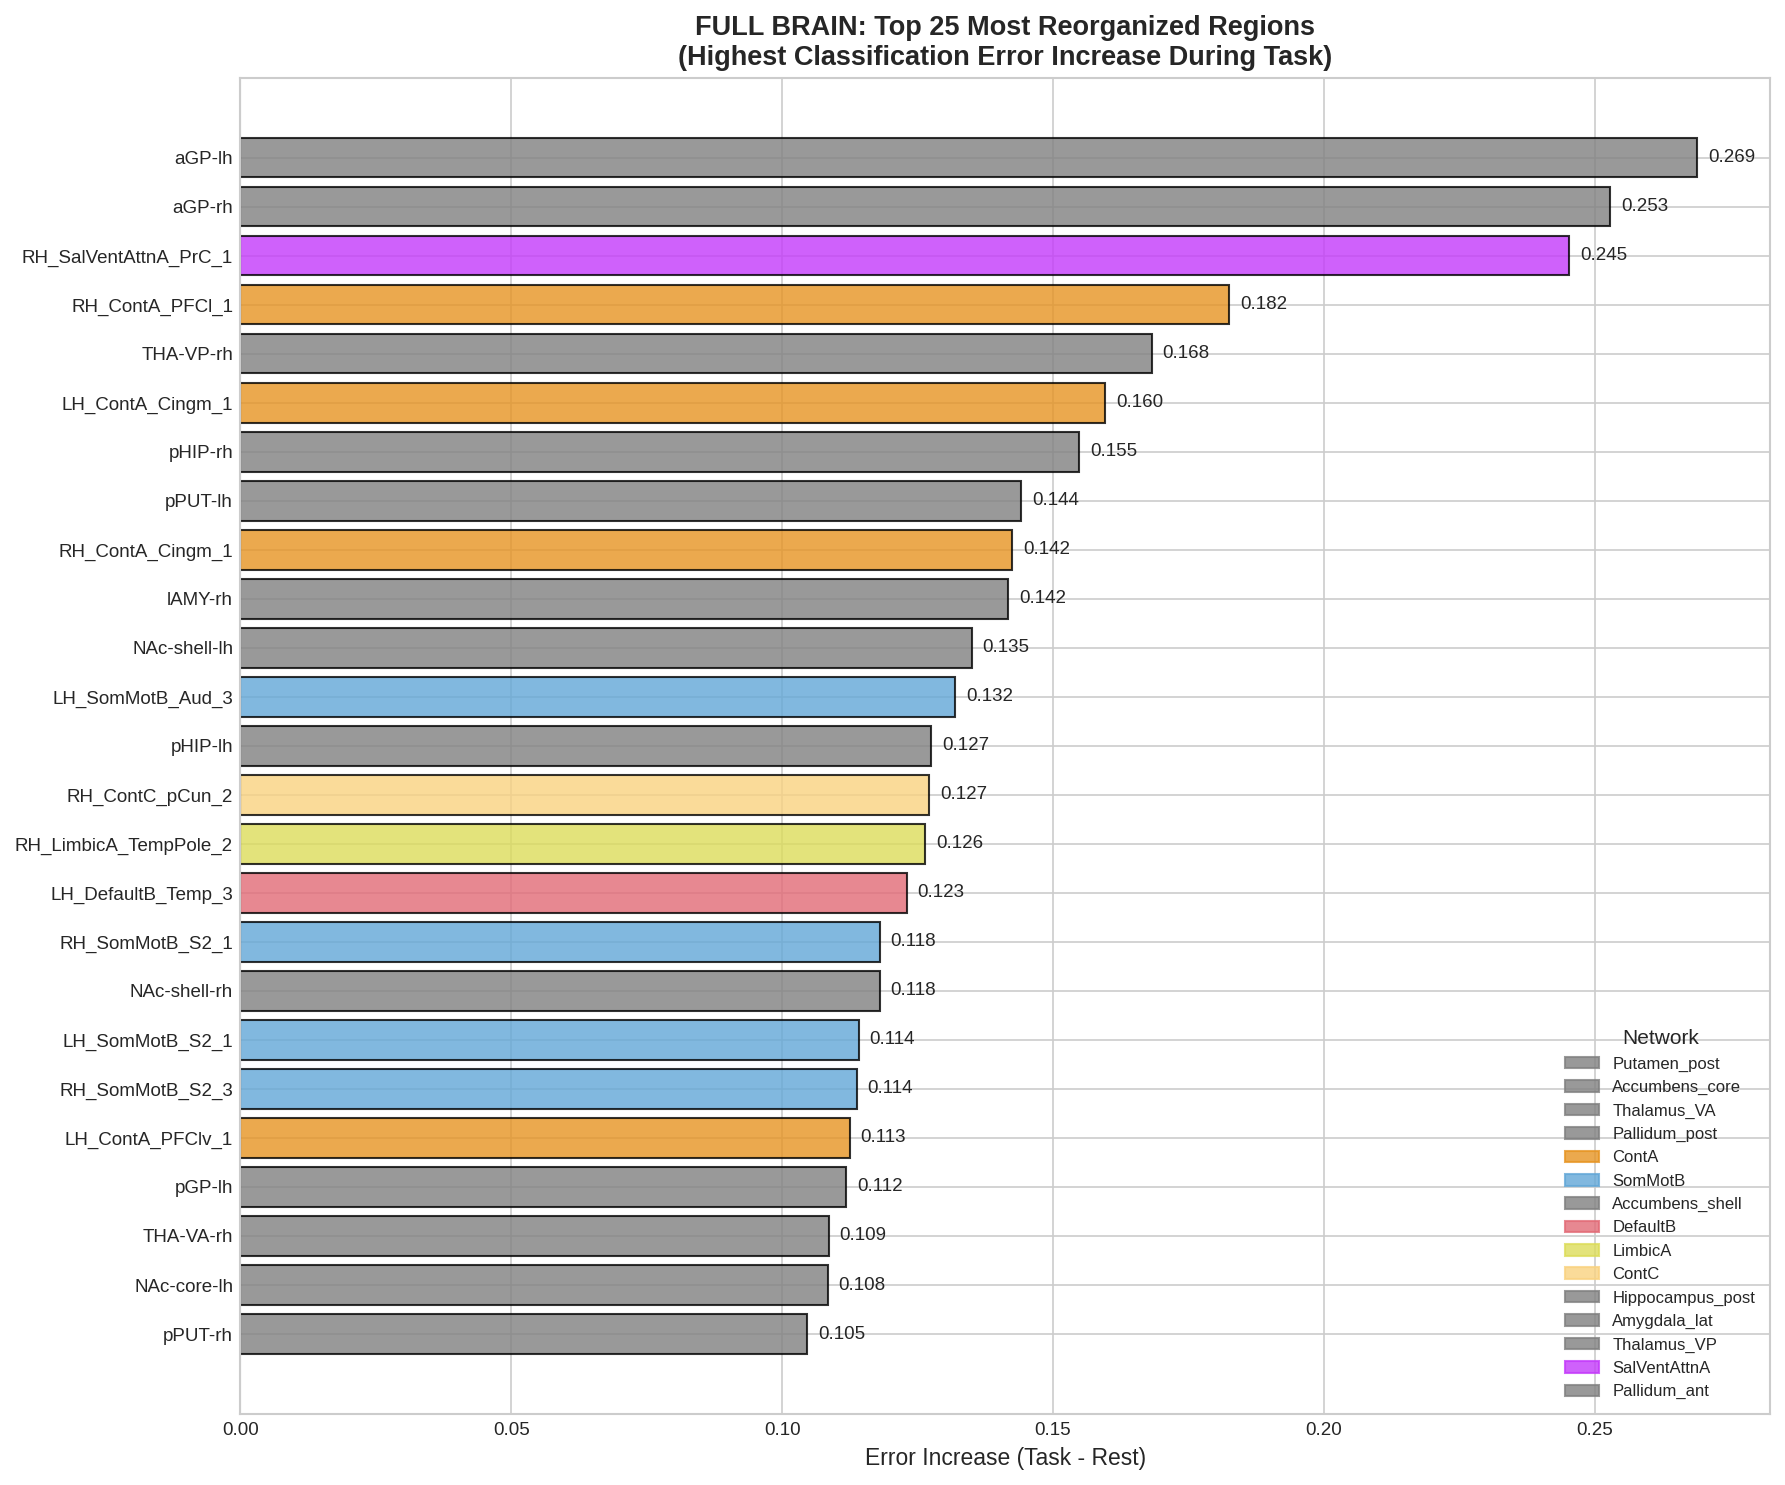

In [17]:
def plot_top_reorganized_regions(df: pd.DataFrame, data_type: str, top_n: int = 20,
                                  save_path: Optional[Path] = None):
    """
    Horizontal bar chart of top reorganized regions.
    """
    # Get top N
    top_df = df.nlargest(top_n, 'error_increase').copy()
    top_df = top_df.iloc[::-1]  # Reverse for plotting (highest at top)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Get colors based on network
    if 'network' in top_df.columns:
        colors = [NETWORK_COLORS.get(net, '#808080') for net in top_df['network']]
    else:
        colors = '#3498db'
    
    # Create horizontal bar chart
    y_pos = np.arange(len(top_df))
    bars = ax.barh(y_pos, top_df['error_increase'], color=colors, alpha=0.8, edgecolor='black')
    
    # Add value labels
    for i, (bar, row) in enumerate(zip(bars, top_df.itertuples())):
        width = bar.get_width()
        ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', va='center', fontsize=9)
    
    # Y-axis labels (region names)
    labels = [f"{row['region_name']}" for _, row in top_df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    
    # Formatting
    ax.set_xlabel('Error Increase (Task - Rest)', fontsize=11)
    ax.set_title(f'{data_type.upper()}: Top {top_n} Most Reorganized Regions\n(Highest Classification Error Increase During Task)',
                 fontsize=13, fontweight='bold')
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    
    # Add legend for networks
    if 'network' in top_df.columns:
        unique_networks = top_df['network'].unique()
        legend_handles = [plt.Rectangle((0,0), 1, 1, color=NETWORK_COLORS.get(net, '#808080'), 
                                         alpha=0.8) for net in unique_networks]
        ax.legend(legend_handles, unique_networks, loc='lower right', title='Network', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()


# Plot for full brain
if 'full' in region_data:
    plot_top_reorganized_regions(
        region_data['full'], 'Full Brain', top_n=25,
        save_path=OUTPUT_DIR / "fig1_top_reorganized_full.png"
    )

✓ Saved: reports/region_level_analysis/fig2_most_stable_full.png


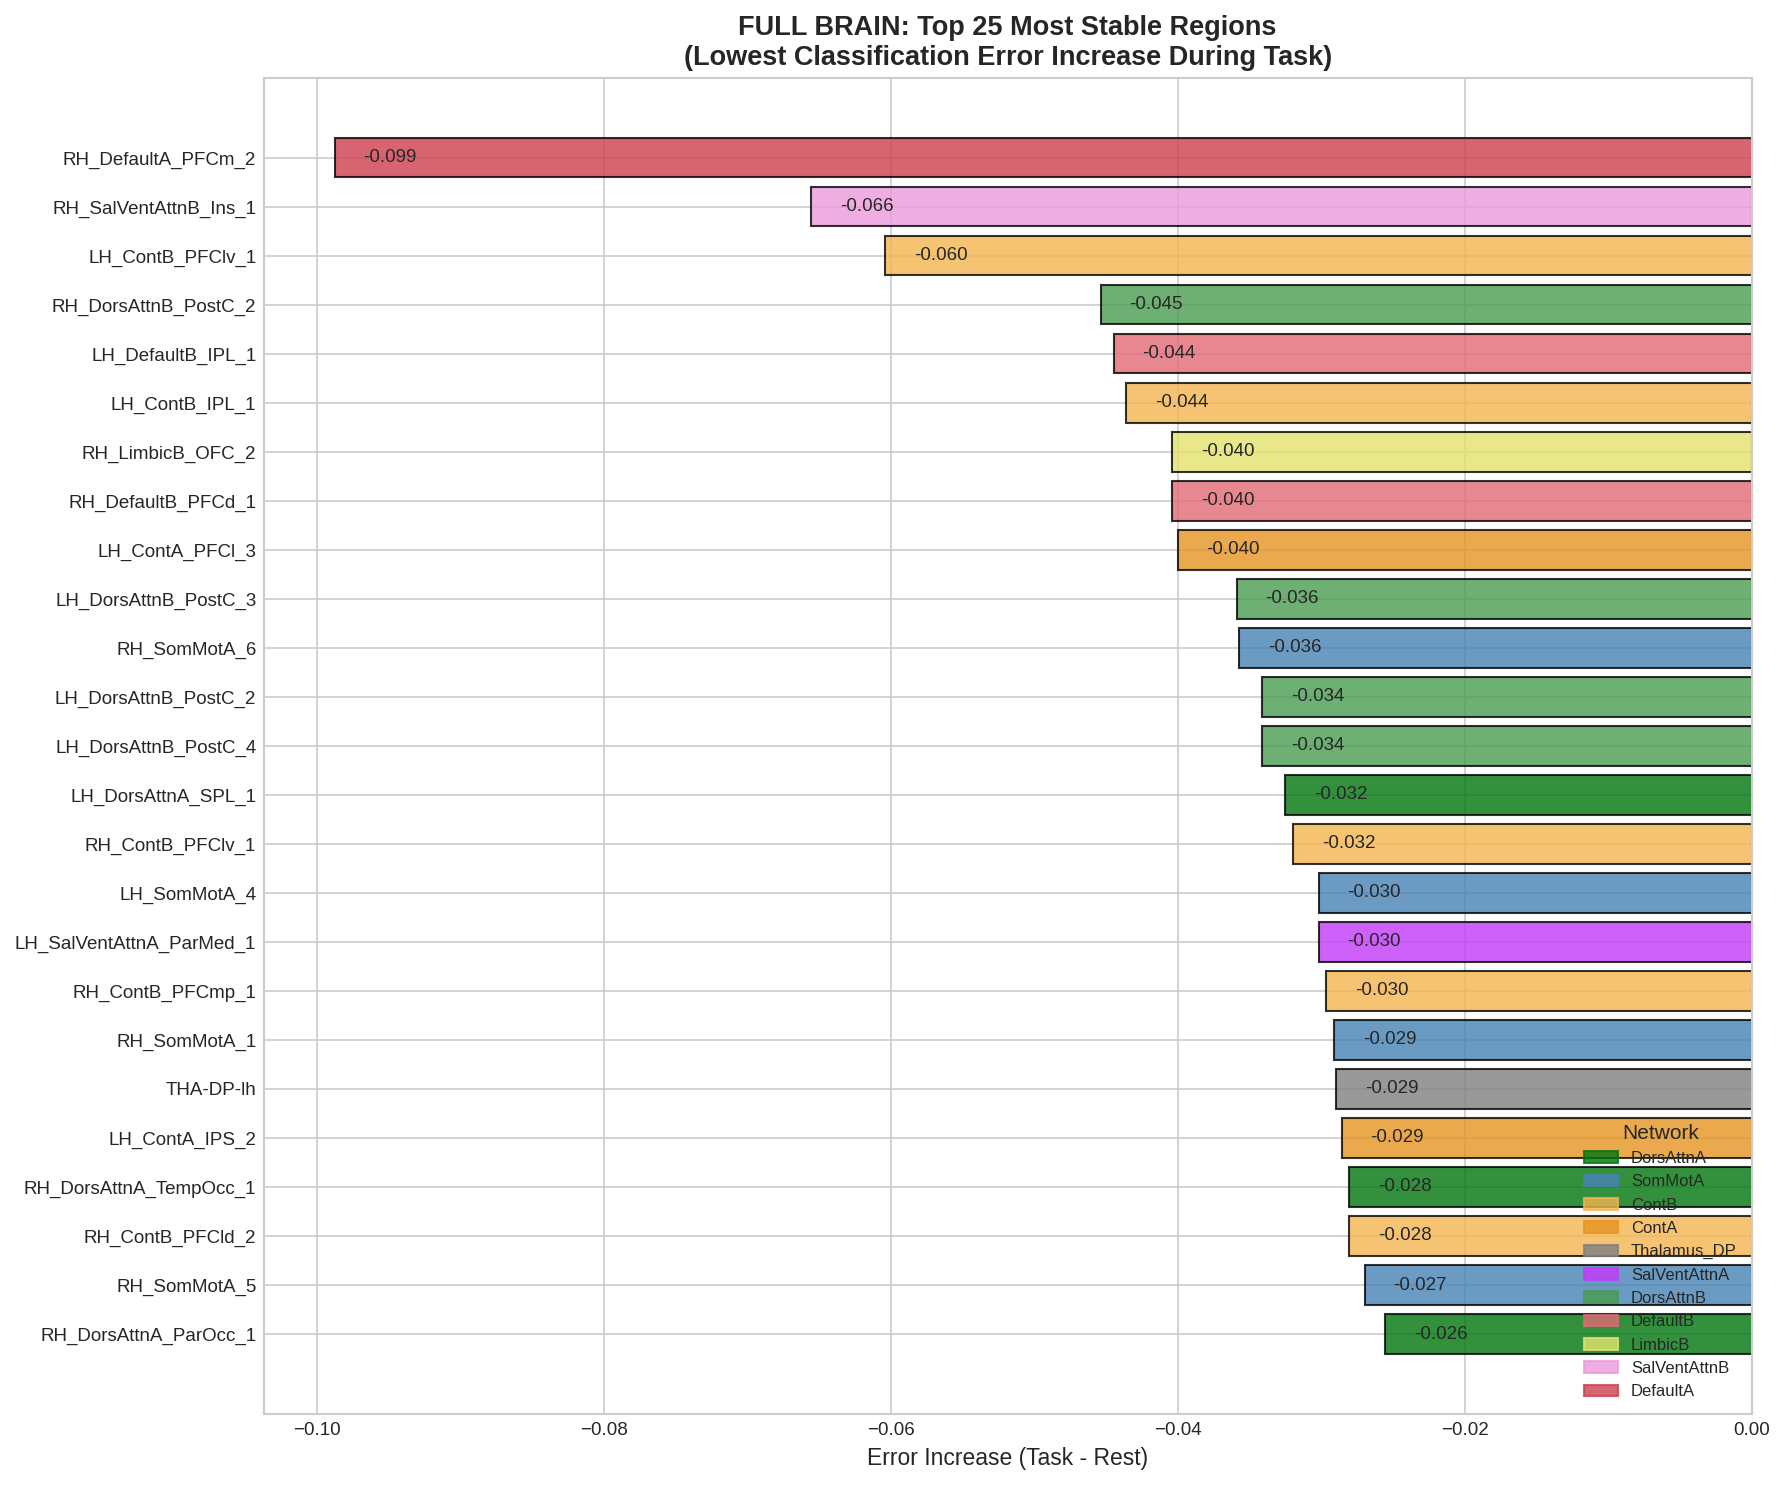

In [18]:
# Cell 7: Visualize Most Stable Regions

def plot_most_stable_regions(df: pd.DataFrame, data_type: str, top_n: int = 20,
                              save_path: Optional[Path] = None):
    """
    Horizontal bar chart of most stable regions (smallest error increase).
    """
    # Get bottom N (most stable)
    stable_df = df.nsmallest(top_n, 'error_increase').copy()
    stable_df = stable_df.iloc[::-1]  # Reverse for plotting
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Get colors based on network
    if 'network' in stable_df.columns:
        colors = [NETWORK_COLORS.get(net, '#808080') for net in stable_df['network']]
    else:
        colors = '#2ecc71'
    
    # Create horizontal bar chart
    y_pos = np.arange(len(stable_df))
    bars = ax.barh(y_pos, stable_df['error_increase'], color=colors, alpha=0.8, edgecolor='black')
    
    # Add value labels
    for i, (bar, row) in enumerate(zip(bars, stable_df.itertuples())):
        width = bar.get_width()
        ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', va='center', fontsize=9)
    
    # Y-axis labels
    labels = [f"{row['region_name']}" for _, row in stable_df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    
    # Formatting
    ax.set_xlabel('Error Increase (Task - Rest)', fontsize=11)
    ax.set_title(f'{data_type.upper()}: Top {top_n} Most Stable Regions\n(Lowest Classification Error Increase During Task)',
                 fontsize=13, fontweight='bold')
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    
    # Add legend for networks
    if 'network' in stable_df.columns:
        unique_networks = stable_df['network'].unique()
        legend_handles = [plt.Rectangle((0,0), 1, 1, color=NETWORK_COLORS.get(net, '#808080'),
                                         alpha=0.8) for net in unique_networks]
        ax.legend(legend_handles, unique_networks, loc='lower right', title='Network', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()


# Plot for full brain
if 'full' in region_data:
    plot_most_stable_regions(
        region_data['full'], 'Full Brain', top_n=25,
        save_path=OUTPUT_DIR / "fig2_most_stable_full.png"
    )


NETWORK-LEVEL AGGREGATION: Full Brain
✓ Saved: reports/region_level_analysis/fig3_network_reorganization.png


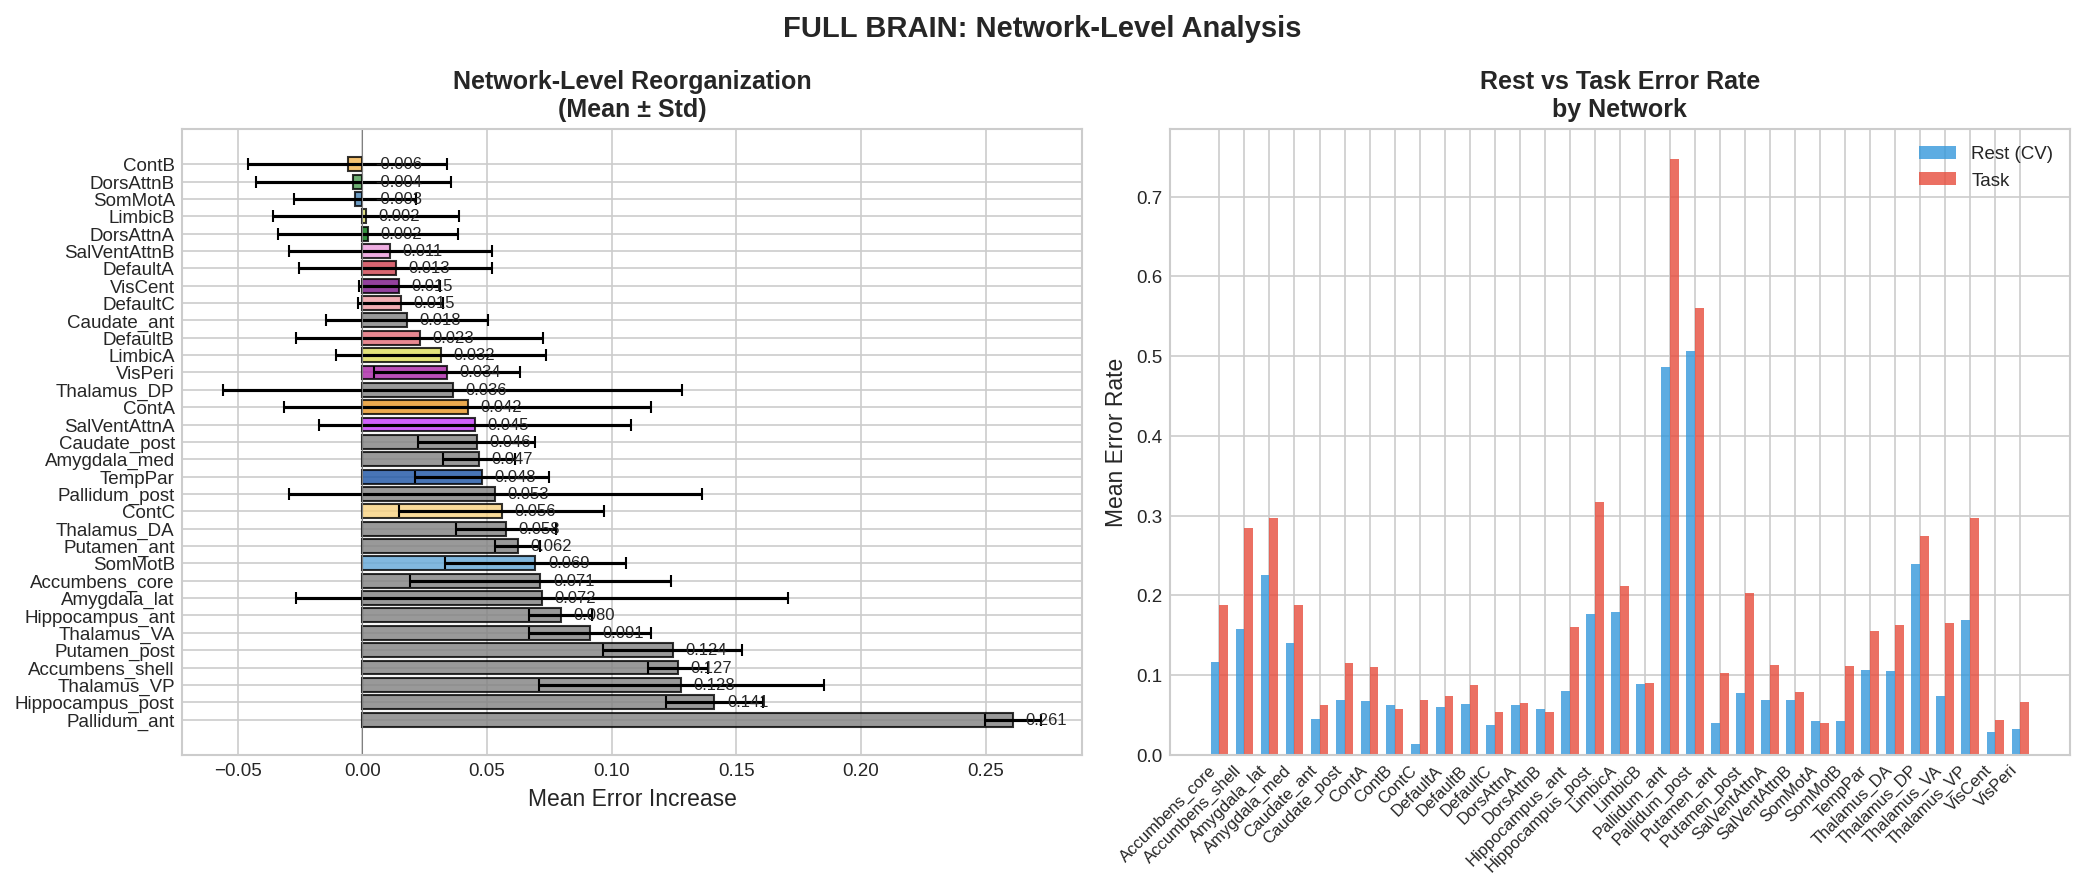


Network Statistics (sorted by reorganization):
         network  n_regions  error_increase_mean  error_increase_std
    Pallidum_ant          2               0.2609              0.0114
Hippocampus_post          2               0.1412              0.0193
     Thalamus_VP          2               0.1279              0.0571
 Accumbens_shell          2               0.1265              0.0120
    Putamen_post          2               0.1244              0.0279
     Thalamus_VA          2               0.0913              0.0244
 Hippocampus_ant          2               0.0796              0.0126
    Amygdala_lat          2               0.0721              0.0986
  Accumbens_core          2               0.0714              0.0523
         SomMotB         15               0.0694              0.0363
     Putamen_ant          2               0.0623              0.0091
     Thalamus_DA          2               0.0576              0.0201
           ContC          6               0.0558       

In [20]:
# Aggregate region-level results to network level for interpretation.

def aggregate_by_network(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-region metrics by network.
    """
    if 'network' not in df.columns:
        print("  ⚠ No network column found")
        return pd.DataFrame()
    
    network_stats = df.groupby('network').agg({
        'cv_error_rate': ['mean', 'std', 'count'],
        'task_error_rate': ['mean', 'std'],
        'error_increase': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    # Flatten column names
    network_stats.columns = ['_'.join(col) for col in network_stats.columns]
    network_stats = network_stats.reset_index()
    network_stats = network_stats.rename(columns={'cv_error_rate_count': 'n_regions'})
    
    # Sort by mean error increase
    network_stats = network_stats.sort_values('error_increase_mean', ascending=False)
    
    return network_stats


def plot_network_reorganization(df: pd.DataFrame, data_type: str, 
                                 save_path: Optional[Path] = None):
    """
    Bar chart of network-level reorganization.
    """
    network_stats = aggregate_by_network(df)
    
    if network_stats.empty:
        print("Cannot create network plot - no network data")
        return None
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Plot 1: Mean error increase by network ---
    ax1 = axes[0]
    
    networks = network_stats['network'].values
    means = network_stats['error_increase_mean'].values
    stds = network_stats['error_increase_std'].values
    colors = [NETWORK_COLORS.get(net, '#808080') for net in networks]
    
    y_pos = np.arange(len(networks))
    bars = ax1.barh(y_pos, means, xerr=stds, capsize=3, 
                    color=colors, alpha=0.8, edgecolor='black')
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(networks, fontsize=9)
    ax1.set_xlabel('Mean Error Increase')
    ax1.set_title('Network-Level Reorganization\n(Mean ± Std)', fontweight='bold')
    ax1.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    
    # Add value labels
    for bar, mean in zip(bars, means):
        width = bar.get_width()
        ax1.text(max(width, 0) + 0.005, bar.get_y() + bar.get_height()/2,
                f'{mean:.3f}', va='center', fontsize=8)
    
    # --- Plot 2: CV vs Task error rate by network ---
    ax2 = axes[1]
    
    # Reorder for this plot (alphabetically for consistency)
    network_stats_sorted = network_stats.sort_values('network')
    networks_s = network_stats_sorted['network'].values
    cv_errors = network_stats_sorted['cv_error_rate_mean'].values
    task_errors = network_stats_sorted['task_error_rate_mean'].values
    
    x = np.arange(len(networks_s))
    width = 0.35
    
    ax2.bar(x - width/2, cv_errors, width, label='Rest (CV)', color='#3498db', alpha=0.8)
    ax2.bar(x + width/2, task_errors, width, label='Task', color='#e74c3c', alpha=0.8)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(networks_s, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('Mean Error Rate')
    ax2.set_title('Rest vs Task Error Rate\nby Network', fontweight='bold')
    ax2.legend()
    
    plt.suptitle(f'{data_type.upper()}: Network-Level Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    
    return network_stats


# Analyze networks for full brain
if 'full' in region_data:
    print("="*80)
    print("NETWORK-LEVEL AGGREGATION: Full Brain")
    print("="*80)
    
    network_stats = plot_network_reorganization(
        region_data['full'], 'Full Brain',
        save_path=OUTPUT_DIR / "fig3_network_reorganization.png"
    )
    
    if network_stats is not None:
        print("\nNetwork Statistics (sorted by reorganization):")
        print(network_stats[['network', 'n_regions', 'error_increase_mean', 
                            'error_increase_std']].to_string(index=False))
        
        # Save
        network_stats.to_csv(OUTPUT_DIR / "network_reorganization_stats.csv", index=False)

In [21]:
# Check if results match expected neuroscience patterns for Gender Stroop task.

def validate_expected_patterns(df: pd.DataFrame, data_type: str):
    """
    Validate results against expected neuroscience patterns.
    """
    print("\n" + "="*80)
    print(f"EXPECTED PATTERNS VALIDATION: {data_type.upper()}")
    print("="*80)
    
    if 'network' not in df.columns:
        print("⚠ Cannot validate - no network information")
        return
    
    # Define expected patterns
    expected = {
        'HIGH_REORG': {
            'networks': ['SomMotA', 'SomMotB', 'Subcortical'],
            'reason': 'Motor response (button press) and task switching'
        },
        'MODERATE_REORG': {
            'networks': ['VisCent', 'VisPeri', 'DorsAttnA', 'DorsAttnB'],
            'reason': 'Visual processing and attention'
        },
        'VARIABLE_REORG': {
            'networks': ['DefaultA', 'DefaultB', 'DefaultC'],
            'reason': 'Task engagement vs default mode suppression'
        },
        'COGNITIVE_CONTROL': {
            'networks': ['ContA', 'ContB', 'ContC', 'SalVentAttnA', 'SalVentAttnB'],
            'reason': 'Conflict detection and resolution in Stroop'
        }
    }
    
    # Calculate mean error increase by network
    network_means = df.groupby('network')['error_increase'].mean().sort_values(ascending=False)
    overall_mean = df['error_increase'].mean()
    
    print(f"\nOverall mean error increase: {overall_mean:.4f}")
    print(f"\nNetwork ranking by reorganization:")
    for i, (net, val) in enumerate(network_means.items(), 1):
        status = "↑ HIGH" if val > overall_mean * 1.2 else ("↓ LOW" if val < overall_mean * 0.8 else "→ MODERATE")
        print(f"  {i:2}. {net:15} : {val:.4f} {status}")
    
    # Validate each expected pattern
    print("\n" + "-"*60)
    print("PATTERN VALIDATION:")
    print("-"*60)
    
    for pattern_name, pattern_info in expected.items():
        print(f"\n{pattern_name}:")
        print(f"  Expected networks: {pattern_info['networks']}")
        print(f"  Reason: {pattern_info['reason']}")
        
        # Get actual values
        pattern_networks = [n for n in pattern_info['networks'] if n in network_means.index]
        if pattern_networks:
            pattern_mean = network_means[pattern_networks].mean()
            relative = pattern_mean / overall_mean
            
            if pattern_name == 'HIGH_REORG':
                status = "✓ CONFIRMED" if relative > 1.1 else "✗ NOT CONFIRMED"
            elif pattern_name == 'MODERATE_REORG':
                status = "✓ CONFIRMED" if 0.8 < relative < 1.2 else "~ PARTIAL"
            else:
                status = f"Relative: {relative:.2f}x mean"
            
            print(f"  Actual mean: {pattern_mean:.4f} ({relative:.2f}x overall mean)")
            print(f"  Status: {status}")
        else:
            print(f"  ⚠ Networks not found in data")
    
    return network_means


# Validate patterns
if 'full' in region_data:
    pattern_results = validate_expected_patterns(region_data['full'], 'Full Brain')


EXPECTED PATTERNS VALIDATION: FULL BRAIN

Overall mean error increase: 0.0317

Network ranking by reorganization:
   1. Pallidum_ant    : 0.2609 ↑ HIGH
   2. Hippocampus_post : 0.1412 ↑ HIGH
   3. Thalamus_VP     : 0.1279 ↑ HIGH
   4. Accumbens_shell : 0.1265 ↑ HIGH
   5. Putamen_post    : 0.1244 ↑ HIGH
   6. Thalamus_VA     : 0.0913 ↑ HIGH
   7. Hippocampus_ant : 0.0796 ↑ HIGH
   8. Amygdala_lat    : 0.0721 ↑ HIGH
   9. Accumbens_core  : 0.0714 ↑ HIGH
  10. SomMotB         : 0.0694 ↑ HIGH
  11. Putamen_ant     : 0.0623 ↑ HIGH
  12. Thalamus_DA     : 0.0576 ↑ HIGH
  13. ContC           : 0.0558 ↑ HIGH
  14. Pallidum_post   : 0.0533 ↑ HIGH
  15. TempPar         : 0.0479 ↑ HIGH
  16. Amygdala_med    : 0.0469 ↑ HIGH
  17. Caudate_post    : 0.0458 ↑ HIGH
  18. SalVentAttnA    : 0.0451 ↑ HIGH
  19. ContA           : 0.0422 ↑ HIGH
  20. Thalamus_DP     : 0.0362 → MODERATE
  21. VisPeri         : 0.0339 → MODERATE
  22. LimbicA         : 0.0316 → MODERATE
  23. DefaultB        : 0.0230 ↓ LOW


HEMISPHERE COMPARISON: Region-Level

Network-level hemisphere comparison:
     network  left_error_increase  right_error_increase  difference more_reorg
       ContC             0.100774              0.192560    0.091786      RIGHT
    DefaultC             0.047024              0.085893    0.038869      RIGHT
   DorsAttnA             0.035238              0.072827    0.037589      RIGHT
   DorsAttnB             0.027786              0.054429    0.026643      RIGHT
     LimbicB             0.059107              0.084152    0.025045      RIGHT
 Subcortical             0.159509              0.182969    0.023460      RIGHT
       ContA             0.078732              0.101339    0.022607      RIGHT
     VisPeri             0.056250              0.078720    0.022470      RIGHT
    DefaultA             0.076071              0.094464    0.018393      RIGHT
       ContB             0.030429              0.044125    0.013696      RIGHT
    DefaultB             0.072734              0.078125 

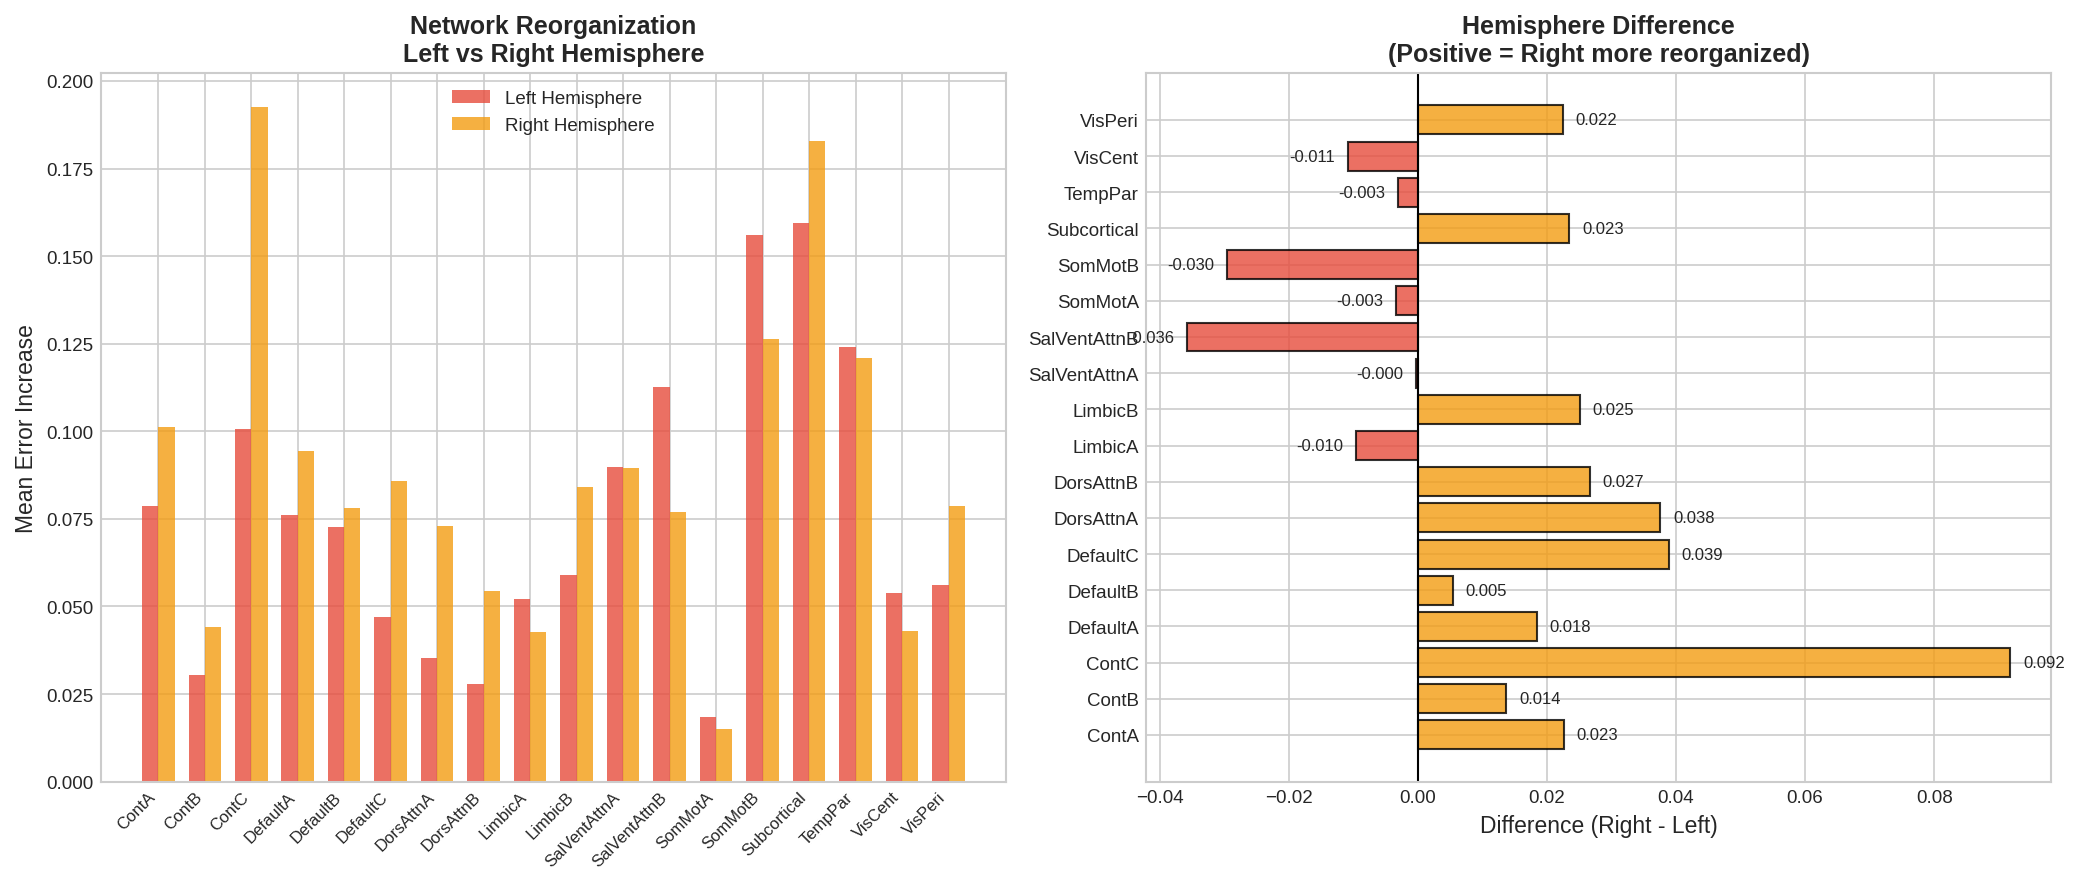

In [22]:
# Compare Hemispheres - Region Level

def compare_hemisphere_regions(left_df: pd.DataFrame, right_df: pd.DataFrame,
                                save_path: Optional[Path] = None):
    """
    Compare region-level reorganization between hemispheres.
    Find matching regions (homologs) and compare their reorganization.
    """
    print("\n" + "="*80)
    print("HEMISPHERE COMPARISON: Region-Level")
    print("="*80)
    
    # Get network-level summary for each hemisphere
    if 'network' in left_df.columns and 'network' in right_df.columns:
        left_net = left_df.groupby('network')['error_increase'].mean()
        right_net = right_df.groupby('network')['error_increase'].mean()
        
        # Combine
        comparison = pd.DataFrame({
            'network': left_net.index,
            'left_error_increase': left_net.values,
            'right_error_increase': right_net.reindex(left_net.index).values
        })
        comparison['difference'] = comparison['right_error_increase'] - comparison['left_error_increase']
        comparison['more_reorg'] = comparison.apply(
            lambda x: 'RIGHT' if x['difference'] > 0 else 'LEFT', axis=1
        )
        
        print("\nNetwork-level hemisphere comparison:")
        print(comparison.sort_values('difference', ascending=False).to_string(index=False))
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Plot 1: Side-by-side comparison
        ax1 = axes[0]
        networks = comparison['network'].values
        x = np.arange(len(networks))
        width = 0.35
        
        ax1.bar(x - width/2, comparison['left_error_increase'], width, 
                label='Left Hemisphere', color='#e74c3c', alpha=0.8)
        ax1.bar(x + width/2, comparison['right_error_increase'], width,
                label='Right Hemisphere', color='#f39c12', alpha=0.8)
        
        ax1.set_xticks(x)
        ax1.set_xticklabels(networks, rotation=45, ha='right', fontsize=8)
        ax1.set_ylabel('Mean Error Increase')
        ax1.set_title('Network Reorganization\nLeft vs Right Hemisphere', fontweight='bold')
        ax1.legend()
        
        # Plot 2: Difference plot
        ax2 = axes[1]
        colors = ['#f39c12' if d > 0 else '#e74c3c' for d in comparison['difference']]
        
        bars = ax2.barh(networks, comparison['difference'], color=colors, alpha=0.8, edgecolor='black')
        ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax2.set_xlabel('Difference (Right - Left)')
        ax2.set_title('Hemisphere Difference\n(Positive = Right more reorganized)', fontweight='bold')
        
        # Add labels
        for bar, diff in zip(bars, comparison['difference']):
            width = bar.get_width()
            ax2.text(width + 0.002 if width >= 0 else width - 0.002,
                    bar.get_y() + bar.get_height()/2,
                    f'{diff:.3f}', va='center', ha='left' if width >= 0 else 'right', fontsize=8)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path)
            print(f"\n✓ Saved: {save_path}")
        
        plt.show()
        
        return comparison
    else:
        print("⚠ Cannot compare - missing network information")
        return None


# Compare hemispheres if both available
if 'left' in region_data and 'right' in region_data:
    hemi_comparison = compare_hemisphere_regions(
        region_data['left'], region_data['right'],
        save_path=OUTPUT_DIR / "fig4_hemisphere_region_comparison.png"
    )

✓ Saved: reports/region_level_analysis/fig5_publication_figure.png


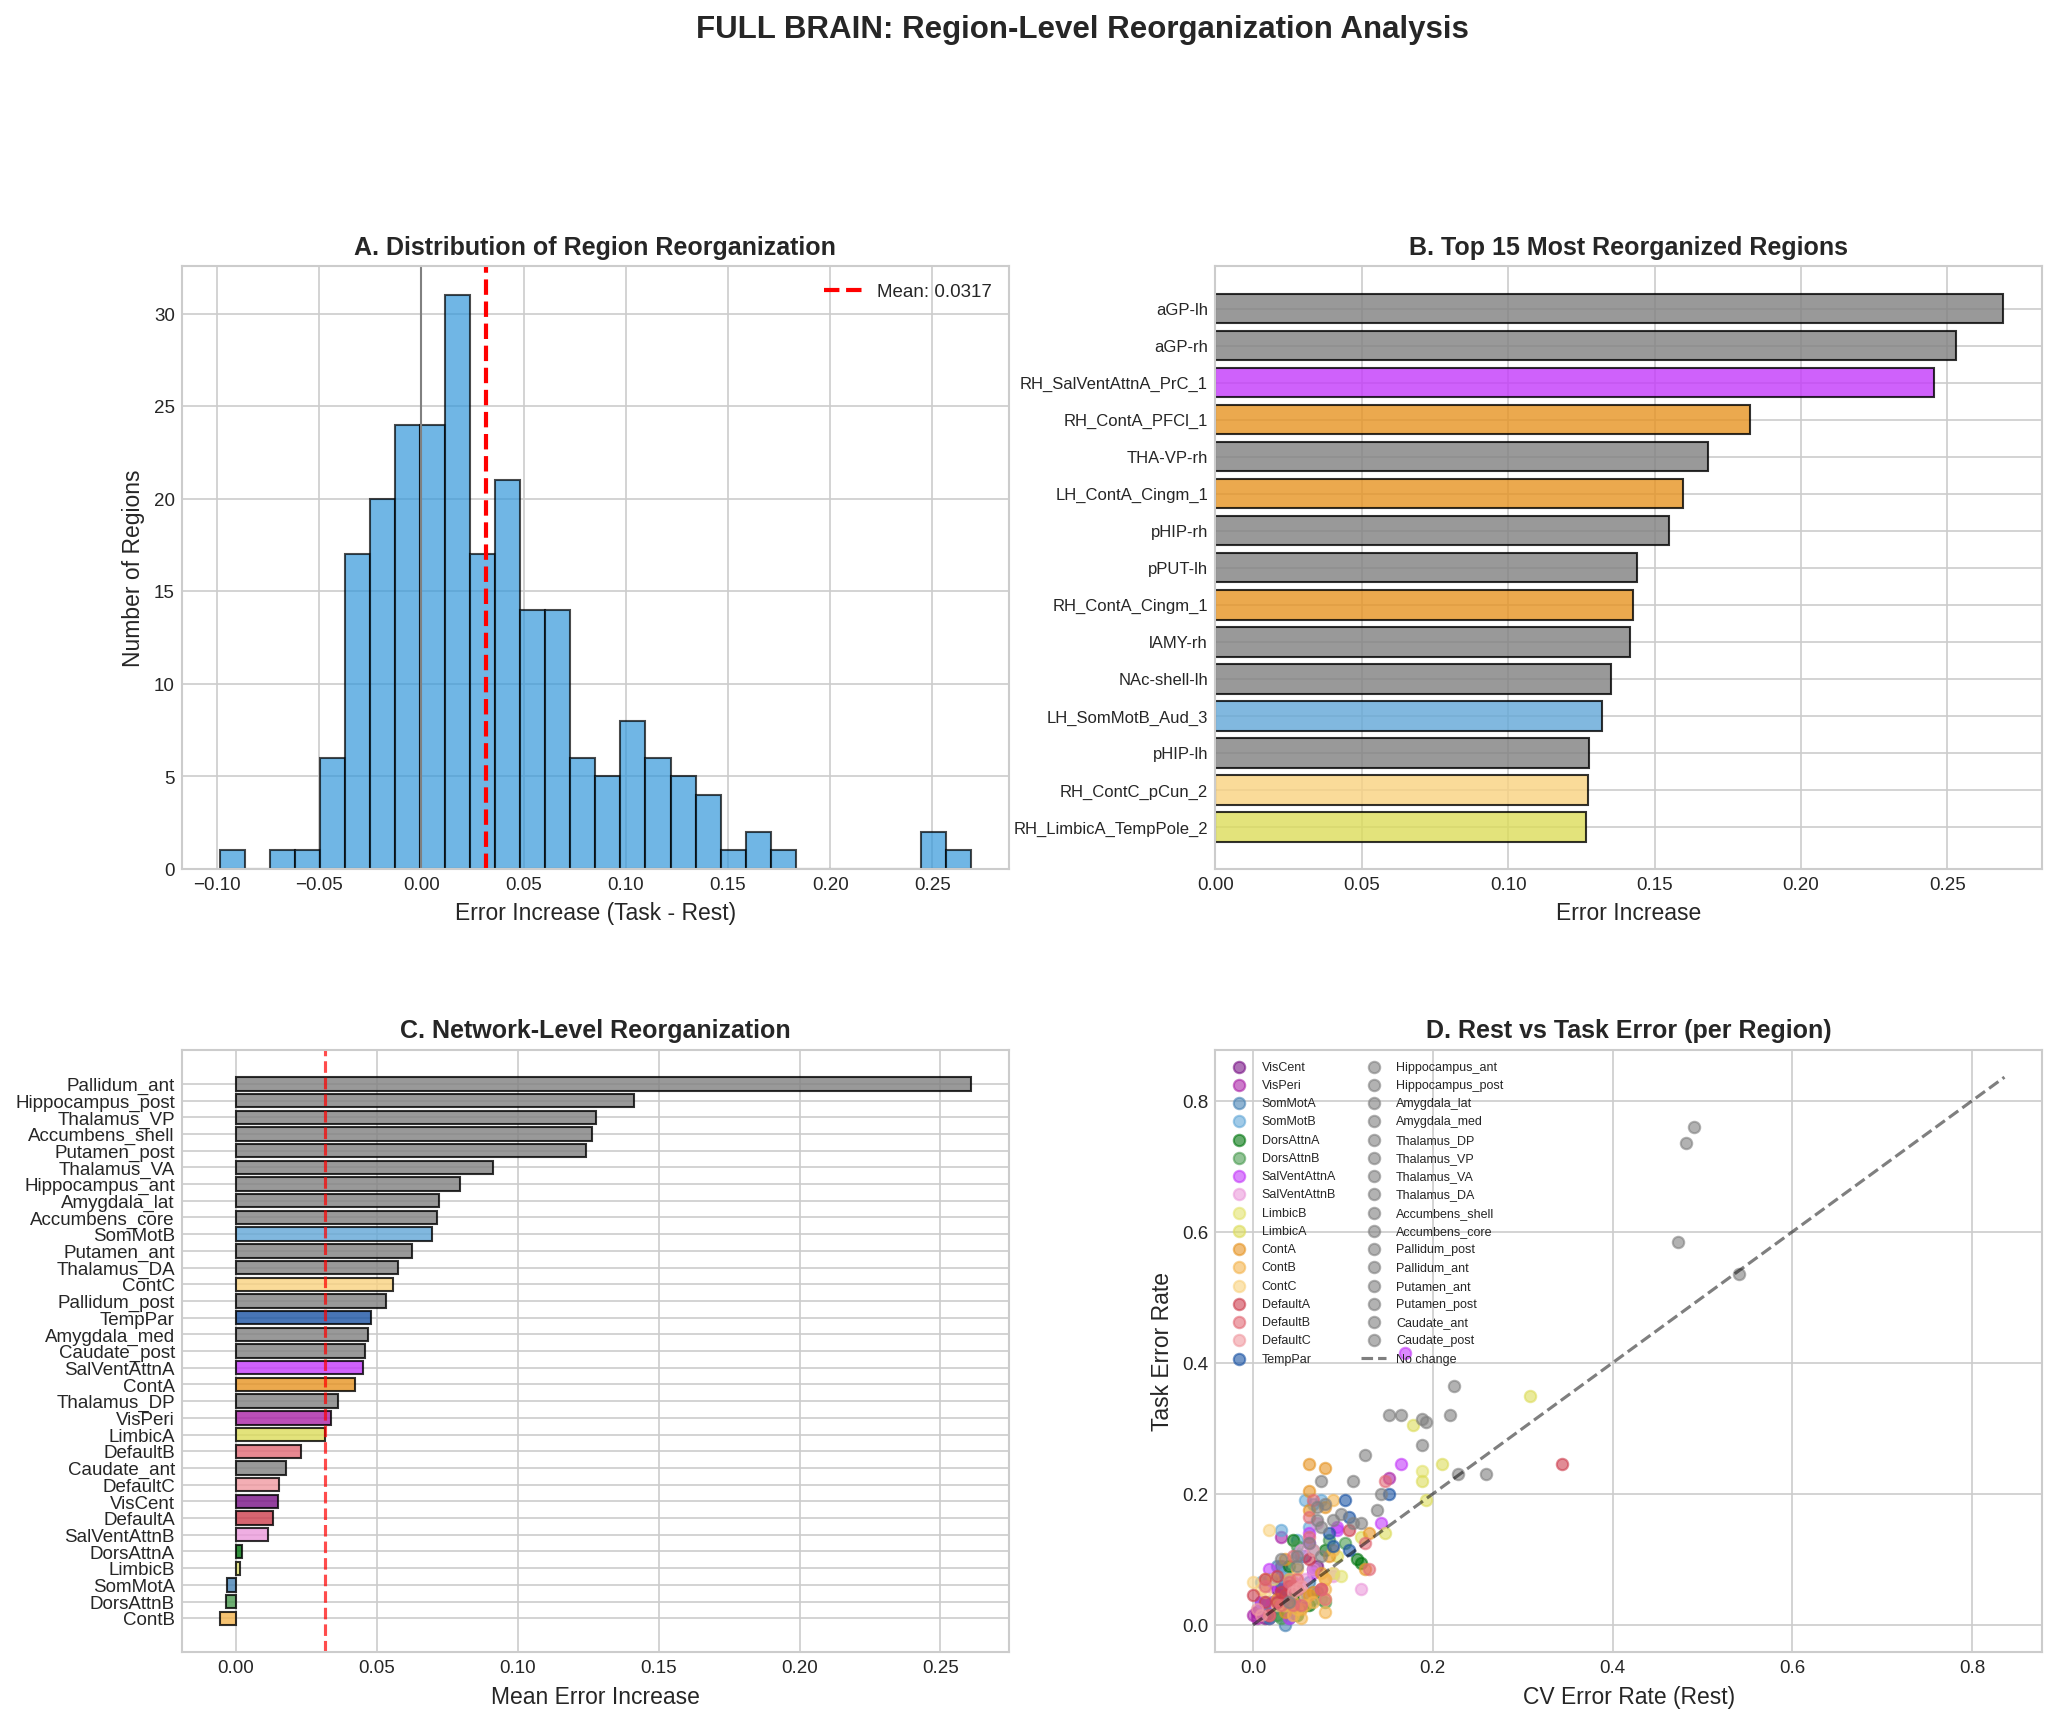

REGION-LEVEL REORGANIZATION: KEY FINDINGS

## FULL (232 regions)

Top 5 Most Reorganized Regions:
  aGP-lh (Pallidum_ant): +0.2689
  aGP-rh (Pallidum_ant): +0.2529
  RH_SalVentAttnA_PrC_1 (SalVentAttnA): +0.2454
  RH_ContA_PFCl_1 (ContA): +0.1825
  THA-VP-rh (Thalamus_VP): +0.1682

Top 5 Most Stable Regions:
  RH_DefaultA_PFCm_2 (DefaultA): -0.0988
  RH_SalVentAttnB_Ins_1 (SalVentAttnB): -0.0655
  LH_ContB_PFClv_1 (ContB): -0.0604
  RH_DorsAttnB_PostC_2 (DorsAttnB): -0.0454
  LH_DefaultB_IPL_1 (DefaultB): -0.0445

Most reorganized network: Pallidum_ant (0.2609)
Most stable network: ContB (-0.0058)

## LEFT (116 regions)

Top 5 Most Reorganized Regions:
  THA-VA-lh (Subcortical): +0.3314
  LH_SomMotB_Cent_1 (SomMotB): +0.2629
  aPUT-lh (Subcortical): +0.2304
  LH_SomMotB_Cent_2 (SomMotB): +0.2264
  pCAU-lh (Subcortical): +0.2200

Top 5 Most Stable Regions:
  LH_LimbicA_TempPole_2 (LimbicA): -0.0443
  LH_ContA_IPS_2 (ContA): -0.0380
  LH_SomMotA_4 (SomMotA): -0.0296
  LH_DorsAttnB_PostC_

In [23]:
# Create comprehensive figure
def create_region_publication_figure(df: pd.DataFrame, data_type: str,
                                      save_path: Optional[Path] = None):
    """
    Create comprehensive publication figure for region-level analysis.
    """
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
    
    # --- Panel A: Distribution of error increase ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    ax1.hist(df['error_increase'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    ax1.axvline(x=df['error_increase'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["error_increase"].mean():.4f}')
    ax1.axvline(x=0, color='gray', linestyle='-', linewidth=1)
    ax1.set_xlabel('Error Increase (Task - Rest)')
    ax1.set_ylabel('Number of Regions')
    ax1.set_title('A. Distribution of Region Reorganization', fontweight='bold')
    ax1.legend()
    
    # --- Panel B: Top 15 most reorganized ---
    ax2 = fig.add_subplot(gs[0, 1])
    
    top_15 = df.nlargest(15, 'error_increase').iloc[::-1]
    y_pos = np.arange(len(top_15))
    
    if 'network' in top_15.columns:
        colors = [NETWORK_COLORS.get(net, '#808080') for net in top_15['network']]
    else:
        colors = '#e74c3c'
    
    ax2.barh(y_pos, top_15['error_increase'], color=colors, alpha=0.8, edgecolor='black')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top_15['region_name'], fontsize=8)
    ax2.set_xlabel('Error Increase')
    ax2.set_title('B. Top 15 Most Reorganized Regions', fontweight='bold')
    
    # --- Panel C: Network-level summary ---
    ax3 = fig.add_subplot(gs[1, 0])
    
    if 'network' in df.columns:
        network_means = df.groupby('network')['error_increase'].mean().sort_values(ascending=True)
        y_pos = np.arange(len(network_means))
        colors = [NETWORK_COLORS.get(net, '#808080') for net in network_means.index]
        
        ax3.barh(y_pos, network_means.values, color=colors, alpha=0.8, edgecolor='black')
        ax3.set_yticks(y_pos)
        ax3.set_yticklabels(network_means.index, fontsize=9)
        ax3.set_xlabel('Mean Error Increase')
        ax3.set_title('C. Network-Level Reorganization', fontweight='bold')
        ax3.axvline(x=df['error_increase'].mean(), color='red', linestyle='--', alpha=0.7)
    else:
        ax3.text(0.5, 0.5, 'No network data', ha='center', va='center', transform=ax3.transAxes)
    
    # --- Panel D: CV vs Task scatter ---
    ax4 = fig.add_subplot(gs[1, 1])
    
    if 'network' in df.columns:
        for network in df['network'].unique():
            net_df = df[df['network'] == network]
            ax4.scatter(net_df['cv_error_rate'], net_df['task_error_rate'],
                       c=NETWORK_COLORS.get(network, '#808080'), alpha=0.6,
                       label=network, s=30)
    else:
        ax4.scatter(df['cv_error_rate'], df['task_error_rate'], alpha=0.6, s=30)
    
    # Add diagonal line (no change)
    lims = [0, max(df['cv_error_rate'].max(), df['task_error_rate'].max()) * 1.1]
    ax4.plot(lims, lims, 'k--', alpha=0.5, label='No change')
    
    ax4.set_xlabel('CV Error Rate (Rest)')
    ax4.set_ylabel('Task Error Rate')
    ax4.set_title('D. Rest vs Task Error (per Region)', fontweight='bold')
    ax4.legend(loc='upper left', fontsize=6, ncol=2)
    
    plt.suptitle(f'{data_type.upper()}: Region-Level Reorganization Analysis',
                 fontsize=15, fontweight='bold', y=1.02)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()


# Create publication figure
if 'full' in region_data:
    create_region_publication_figure(
        region_data['full'], 'Full Brain',
        save_path=OUTPUT_DIR / "fig5_publication_figure.png"
    )

# %% [markdown]
# ## Cell 12: Generate Key Findings Summary

# %%
def generate_region_findings(data: Dict[str, pd.DataFrame]) -> str:
    """
    Generate thesis-ready summary of region-level findings.
    """
    lines = []
    lines.append("="*80)
    lines.append("REGION-LEVEL REORGANIZATION: KEY FINDINGS")
    lines.append("="*80)
    
    for data_type, df in data.items():
        lines.append(f"\n## {data_type.upper()} ({len(df)} regions)")
        
        # Top reorganized regions
        top_5 = df.nlargest(5, 'error_increase')
        lines.append(f"\nTop 5 Most Reorganized Regions:")
        for i, row in top_5.iterrows():
            net = row.get('network', 'N/A')
            lines.append(f"  {row['region_name']} ({net}): +{row['error_increase']:.4f}")
        
        # Most stable regions
        bottom_5 = df.nsmallest(5, 'error_increase')
        lines.append(f"\nTop 5 Most Stable Regions:")
        for i, row in bottom_5.iterrows():
            net = row.get('network', 'N/A')
            lines.append(f"  {row['region_name']} ({net}): {row['error_increase']:.4f}")
        
        # Network summary
        if 'network' in df.columns:
            network_means = df.groupby('network')['error_increase'].mean()
            lines.append(f"\nMost reorganized network: {network_means.idxmax()} ({network_means.max():.4f})")
            lines.append(f"Most stable network: {network_means.idxmin()} ({network_means.min():.4f})")
    
    # Interpretation
    lines.append("\n" + "="*80)
    lines.append("INTERPRETATION FOR GENDER STROOP TASK")
    lines.append("="*80)
    
    lines.append("""
The region-level analysis reveals which brain areas undergo the most 
functional reorganization during the Gender Stroop task:

1. MOTOR REGIONS: Expected high reorganization due to button-press 
   responses required during task performance.

2. SUBCORTICAL STRUCTURES: High reorganization reflects involvement
   in task switching, attention, and cognitive control.

3. VISUAL REGIONS: Moderate reorganization from processing face 
   stimuli and word reading.

4. DEFAULT MODE NETWORK: Variable reorganization reflecting 
   suppression during task engagement.

5. COGNITIVE CONTROL NETWORKS: Reorganization related to conflict
   detection (gender word vs. face gender incongruence).

These patterns validate that classification errors are meaningful 
biological signals reflecting task-induced functional changes.
""")
    
    lines.append("="*80)
    
    return "\n".join(lines)


# Generate findings
if region_data:
    findings = generate_region_findings(region_data)
    print(findings)
    
    # Save
    with open(OUTPUT_DIR / "region_findings_summary.txt", 'w') as f:
        f.write(findings)
    print(f"\n✓ Saved: {OUTPUT_DIR / 'region_findings_summary.txt'}")

# %% [markdown]
# ## Cell 13: Save All Results

# %%
# Save ranked regions for each data type
for data_type, rank_data in rankings.items():
    # Save full ranked list
    output_path = OUTPUT_DIR / f"ranked_regions_{data_type}.csv"
    rank_data['full'].to_csv(output_path, index=False)
    print(f"✓ Saved: {output_path}")
    
    # Save top 50 most reorganized
    top_path = OUTPUT_DIR / f"top50_reorganized_{data_type}.csv"
    rank_data['full'].head(50).to_csv(top_path, index=False)
    print(f"✓ Saved: {top_path}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE: Region-Level Reorganization Ranking")
print("="*80)
print(f"\nOutput directory: {OUTPUT_DIR}")
print("\nGenerated files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  • {f.name}")

In [ ]:
# Create quick reference tables for thesis
if 'full' in region_data:
    df = region_data['full']
    
    print("\n" + "="*80)
    print("QUICK REFERENCE: Top 20 Regions for Thesis Table")
    print("="*80)
    
    top_20 = df.nlargest(20, 'error_increase')[
        ['region_name', 'network', 'cv_error_rate', 'task_error_rate', 'error_increase']
    ].round(4)
    
    print("\n--- Copy this for your thesis ---")
    print(top_20.to_latex(index=False) if hasattr(top_20, 'to_latex') else top_20.to_string(index=False))
    
    # Save as formatted table
    top_20.to_csv(OUTPUT_DIR / "thesis_table_top20_regions.csv", index=False)
    print(f"\n✓ Saved: {OUTPUT_DIR / 'thesis_table_top20_regions.csv'}")


QUICK REFERENCE: Top 20 Regions for Thesis Table

--- Copy this for your thesis ---
\begin{tabular}{llrrr}
\toprule
region_name & network & cv_error_rate & task_error_rate & error_increase \\
\midrule
aGP-lh & Pallidum_ant & 0.491100 & 0.760000 & 0.268900 \\
aGP-rh & Pallidum_ant & 0.482100 & 0.735000 & 0.252900 \\
RH_SalVentAttnA_PrC_1 & SalVentAttnA & 0.169600 & 0.415000 & 0.245400 \\
RH_ContA_PFCl_1 & ContA & 0.062500 & 0.245000 & 0.182500 \\
THA-VP-rh & Thalamus_VP & 0.151800 & 0.320000 & 0.168200 \\
LH_ContA_Cingm_1 & ContA & 0.080400 & 0.240000 & 0.159600 \\
pHIP-rh & Hippocampus_post & 0.165200 & 0.320000 & 0.154800 \\
pPUT-lh & Putamen_post & 0.075900 & 0.220000 & 0.144100 \\
RH_ContA_Cingm_1 & ContA & 0.062500 & 0.205000 & 0.142500 \\
lAMY-rh & Amygdala_lat & 0.223200 & 0.365000 & 0.141800 \\
NAc-shell-lh & Accumbens_shell & 0.125000 & 0.260000 & 0.135000 \\
LH_SomMotB_Aud_3 & SomMotB & 0.058000 & 0.190000 & 0.132000 \\
pHIP-lh & Hippocampus_post & 0.187500 & 0.315000 & 0.127